# Multi-Classifier Comparison on PLV + BE Features

Same features as `SVM_PLV/svm_plv_be_combined.ipynb` (per-modality StandardScaler -> PCA 95% -> concat -> post StandardScaler), but swap SVM for multiple classifiers and compare.

In [ ]:
import os
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('xgboost not installed - skipping')

try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print('lightgbm not installed - skipping')

In [ ]:
# Channel groups
CH_NAMES = [
    'Fp1','Fz','F3','F7','FT9','FC5','FC1',
    'C3','T7','TP9','CP5','CP1','Pz','P3','P7',
    'O1','Oz','O2',
    'P4','P8','TP10','CP6','CP2','Cz','C4','T8',
    'FT10','FC6','FC2','F4','F8','Fp2'
]
REGIONS = {
    'Frontal':   [0, 31, 2, 29, 3, 30, 1],
    'Central':   [7, 24, 23, 6, 28, 5, 27],
    'Parietal':  [13, 18, 14, 19, 12, 11, 22, 10, 21],
    'Temporal':  [8, 25, 4, 26, 9, 20],
    'Occipital': [15, 17, 16],
}
BAND_NAMES = ['delta', 'theta', 'alpha', 'beta', 'gamma']
CLASS_NAMES = ['amateur', 'master', 'prof']

In [ ]:
# Load PLV & Band Energy (same as SVM_PLV version)
def get_subject_id(fn):
    return fn.split('_ses-')[0]

def scan_folder(folder):
    return {get_subject_id(f): os.path.join(folder, f)
            for f in sorted(os.listdir(folder)) if f.endswith('.mat')}

def load_plv(fp):
    with h5py.File(fp, 'r') as f:
        rm = f['result_mats']
        return np.array([np.array(rm[b]) for b in BAND_NAMES])

def load_plv_group(m1, m2, m3, subs):
    X1, X2, X3 = [], [], []
    for s in subs:
        X1.append(load_plv(m1[s])); X2.append(load_plv(m2[s])); X3.append(load_plv(m3[s]))
    return np.array(X1), np.array(X2), np.array(X3)

def load_band_energy(fp):
    with h5py.File(fp, 'r') as f:
        return np.array(f['band_energy']).T

def load_be_group(m1, m2, m3, subs):
    X1, X2, X3 = [], [], []
    for s in subs:
        X1.append(load_band_energy(m1[s])); X2.append(load_band_energy(m2[s])); X3.append(load_band_energy(m3[s]))
    return np.array(X1), np.array(X2), np.array(X3)

BASE_PLV = {
    'amateur': r'D:\Tseng\圍棋\amateur\PLV_Results_2026',
    'master':  r'D:\Tseng\圍棋\master\PLV_Results_2026',
    'prof':    r'D:\Tseng\圍棋\prof\PLV_Results_2026',
}
BASE_BE = {
    'amateur': r'D:\Tseng\圍棋\amateur\band_energy_batch_outputs_2026',
    'master':  r'D:\Tseng\圍棋\master\band_energy_batch_outputs_2026',
    'prof':    r'D:\Tseng\圍棋\prof\band_energy_batch_outputs_2026',
}

plv_maps, complete = {}, {}
for g in CLASS_NAMES:
    paths = {s: os.path.join(BASE_PLV[g], s) for s in ['ss01','ss02','ss03']}
    m1, m2, m3 = scan_folder(paths['ss01']), scan_folder(paths['ss02']), scan_folder(paths['ss03'])
    plv_maps[g] = (m1, m2, m3)
    complete[g] = sorted(set(m1) & set(m2) & set(m3))
    print(f'[{g}] complete subjects: {len(complete[g])}')

print('Loading PLV...')
X_a1, X_a2, X_a3 = load_plv_group(*plv_maps['amateur'], complete['amateur'])
X_m1, X_m2, X_m3 = load_plv_group(*plv_maps['master'],  complete['master'])
X_p1, X_p2, X_p3 = load_plv_group(*plv_maps['prof'],    complete['prof'])
print(f'PLV shapes: {X_a1.shape}, {X_m1.shape}, {X_p1.shape}')

print('Loading Band Energy...')
be_maps = {}
for g in CLASS_NAMES:
    paths = {s: os.path.join(BASE_BE[g], s) for s in ['ss01','ss02','ss03']}
    be_maps[g] = (scan_folder(paths['ss01']), scan_folder(paths['ss02']), scan_folder(paths['ss03']))
BE_a1, BE_a2, BE_a3 = load_be_group(*be_maps['amateur'], complete['amateur'])
BE_m1, BE_m2, BE_m3 = load_be_group(*be_maps['master'],  complete['master'])
BE_p1, BE_p2, BE_p3 = load_be_group(*be_maps['prof'],    complete['prof'])
print(f'BE shape: {BE_a1.shape}')

[amateur] complete subjects: 28
[master] complete subjects: 20
[prof] complete subjects: 8
Loading PLV...
PLV shapes: (28, 5, 200, 32, 32), (20, 5, 200, 32, 32), (8, 5, 200, 32, 32)
Loading Band Energy...
BE shape: (28, 32, 39, 5)


In [ ]:
# Feature extraction & label prep
triu_idx = np.triu_indices(32, k=1)

def extract_plv_features(X, ch_idx=None):
    X_mean = X.mean(axis=2)
    if ch_idx is not None:
        X_mean = X_mean[:, :, np.ix_(ch_idx, ch_idx)[0], np.ix_(ch_idx, ch_idx)[1]]
        tri = np.triu_indices(len(ch_idx), k=1)
    else:
        tri = triu_idx
    return np.hstack([X_mean[:, b, tri[0], tri[1]] for b in range(5)])

def extract_be_features(X_be, ch_idx=None):
    X = np.log(X_be + 1e-8)
    X = X[:, :, 1:-1, :].mean(axis=2)
    if ch_idx is not None:
        X = X[:, ch_idx, :]
    return X.reshape(len(X), -1)

n_a, n_m, n_p = len(complete['amateur']), len(complete['master']), len(complete['prof'])

plv_all = []
for g in CLASS_NAMES:
    for x in {'amateur': [X_a1,X_a2,X_a3], 'master': [X_m1,X_m2,X_m3], 'prof': [X_p1,X_p2,X_p3]}[g]:
        plv_all.append(x)
X_plv = np.vstack(plv_all)

be_all = []
for g in CLASS_NAMES:
    for x in {'amateur': [BE_a1,BE_a2,BE_a3], 'master': [BE_m1,BE_m2,BE_m3], 'prof': [BE_p1,BE_p2,BE_p3]}[g]:
        be_all.append(x)
X_be = np.vstack(be_all)

y_all = np.concatenate([np.zeros(n_a*3), np.ones(n_m*3), np.full(n_p*3, 2)])
subject_ids = complete['amateur'] + complete['master'] + complete['prof']
subject_split = np.concatenate([
    np.repeat(complete['amateur'], 3),
    np.repeat(complete['master'], 3),
    np.repeat(complete['prof'], 3),
])
subject_labels = {}
for g_idx, g in enumerate(CLASS_NAMES):
    for s in complete[g]:
        subject_labels[s] = g_idx

print(f'X_plv: {X_plv.shape}  X_be: {X_be.shape}  y: {y_all.shape}')

X_plv: (168, 5, 200, 32, 32)  X_be: (168, 32, 39, 5)  y: (168,)


In [ ]:
# Generic LOSO runner that works with any classifier factory
def run_loso_combined_clf(X_plv, X_be, ch_idx, y_all, subject_split, subject_ids, subject_labels,
                          classifier_factory, pca_variance=0.95, post_scale=True):
    feat_plv = extract_plv_features(X_plv, ch_idx)
    feat_be  = extract_be_features(X_be, ch_idx)

    all_preds, all_true, all_proba = [], [], []
    per_sub = []

    for test_subject in subject_ids:
        test_mask  = subject_split == test_subject
        train_mask = ~test_mask

        y_tr = y_all[train_mask].astype(int)
        y_te = y_all[test_mask].astype(int)

        plv_tr, plv_te = feat_plv[train_mask], feat_plv[test_mask]
        sc_plv = StandardScaler()
        plv_tr = sc_plv.fit_transform(plv_tr); plv_te = sc_plv.transform(plv_te)
        pca_plv = PCA(n_components=pca_variance)
        plv_tr = pca_plv.fit_transform(plv_tr); plv_te = pca_plv.transform(plv_te)

        be_tr, be_te = feat_be[train_mask], feat_be[test_mask]
        sc_be = StandardScaler()
        be_tr = sc_be.fit_transform(be_tr); be_te = sc_be.transform(be_te)
        pca_be = PCA(n_components=pca_variance)
        be_tr = pca_be.fit_transform(be_tr); be_te = pca_be.transform(be_te)

        X_tr = np.hstack([plv_tr, be_tr])
        X_te = np.hstack([plv_te, be_te])
        if post_scale:
            sc_final = StandardScaler()
            X_tr = sc_final.fit_transform(X_tr); X_te = sc_final.transform(X_te)

        clf = classifier_factory()
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)
        if hasattr(clf, 'predict_proba'):
            proba = clf.predict_proba(X_te)
        else:
            proba = np.zeros((len(y_te), 3))
            for i, p in enumerate(preds):
                proba[i, int(p)] = 1.0

        per_sub.append({
            'subject': test_subject,
            'true': subject_labels[test_subject],
            'acc': accuracy_score(y_te, preds),
            'f1':  f1_score(y_te, preds, average='macro', zero_division=0),
        })
        all_preds.extend(preds); all_true.extend(y_te); all_proba.extend(proba)

    return np.array(all_preds), np.array(all_true), np.array(all_proba), per_sub

In [ ]:
# Classifier factories - same features, different ML tools
classifiers = {
    'SVM-RBF':      lambda: SVC(kernel='rbf', C=10, gamma='scale',
                                class_weight='balanced', probability=True, random_state=42),
    'LogReg':       lambda: LogisticRegression(max_iter=5000, C=1.0,
                                class_weight='balanced', random_state=42),
    'LDA':          lambda: LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),
    'KNN-5':        lambda: KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'GaussianNB':   lambda: GaussianNB(),
    'RandomForest': lambda: RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                random_state=42, n_jobs=-1),
    'ExtraTrees':   lambda: ExtraTreesClassifier(n_estimators=300, class_weight='balanced',
                                random_state=42, n_jobs=-1),
    'GradBoost':    lambda: GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                max_depth=3, random_state=42),
    'MLP':          lambda: MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000,
                                early_stopping=True, random_state=42),
}
if HAS_XGB:
    classifiers['XGBoost'] = lambda: XGBClassifier(n_estimators=300, learning_rate=0.05,
                                max_depth=4, tree_method='hist', eval_metric='mlogloss',
                                random_state=42, verbosity=0)
if HAS_LGB:
    classifiers['LightGBM'] = lambda: LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                num_leaves=31, random_state=42, verbosity=-1)

print(f'Classifiers to evaluate ({len(classifiers)}):')
for k in classifiers:
    print(f'  - {k}')

Classifiers to evaluate (11):
  - SVM-RBF
  - LogReg
  - LDA
  - KNN-5
  - GaussianNB
  - RandomForest
  - ExtraTrees
  - GradBoost
  - MLP
  - XGBoost
  - LightGBM


In [ ]:
# Run every classifier x every region  (this may take a few minutes)
import time

results = {}
for clf_name, factory in classifiers.items():
    t0 = time.time()
    results[clf_name] = {}
    row_line = f'[{clf_name:<13s}] '
    for region_name, ch_idx in REGIONS.items():
        preds, true, proba, per_sub = run_loso_combined_clf(
            X_plv, X_be, ch_idx, y_all, subject_split, subject_ids, subject_labels,
            factory, pca_variance=0.95, post_scale=True)
        acc = accuracy_score(true, preds)
        f1  = f1_score(true, preds, average='macro', zero_division=0)
        results[clf_name][region_name] = {
            'acc': acc, 'f1': f1, 'preds': preds, 'true': true,
            'proba': proba, 'per_sub': per_sub, 'ch_idx': ch_idx,
        }
        row_line += f'{region_name[:4]}={acc:.3f} '
    elapsed = time.time() - t0
    print(row_line + f' ({elapsed:.1f}s)')

[SVM-RBF      ] Fron=0.708 Cent=0.744 Pari=0.839 Temp=0.619 Occi=0.536  (8.3s)
[LogReg       ] Fron=0.542 Cent=0.518 Pari=0.583 Temp=0.405 Occi=0.327  (7.2s)
[LDA          ] Fron=0.530 Cent=0.500 Pari=0.577 Temp=0.512 Occi=0.470  (6.2s)
[KNN-5        ] Fron=0.631 Cent=0.696 Pari=0.762 Temp=0.595 Occi=0.595  (9.1s)
[GaussianNB   ] Fron=0.506 Cent=0.536 Pari=0.631 Temp=0.470 Occi=0.482  (5.5s)
[RandomForest ] Fron=0.649 Cent=0.649 Pari=0.738 Temp=0.565 Occi=0.565  (140.8s)
[ExtraTrees   ] Fron=0.696 Cent=0.679 Pari=0.810 Temp=0.661 Occi=0.601  (121.7s)
[GradBoost    ] Fron=0.577 Cent=0.619 Pari=0.720 Temp=0.595 Occi=0.518  (287.2s)
[MLP          ] Fron=0.321 Cent=0.435 Pari=0.500 Temp=0.452 Occi=0.369  (11.8s)
[XGBoost      ] Fron=0.595 Cent=0.637 Pari=0.702 Temp=0.595 Occi=0.506  (114.8s)


c:\Users\user\anaconda3\envs\game_eeg\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\game_eeg\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\game_eeg\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\game_eeg\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\game_eeg\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with f

[LightGBM     ] Fron=0.613 Cent=0.667 Pari=0.732 Temp=0.589 Occi=0.536  (33.1s)


c:\Users\user\anaconda3\envs\game_eeg\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\game_eeg\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\game_eeg\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\game_eeg\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\user\anaconda3\envs\game_eeg\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with f

In [ ]:
# Comparison table
region_names = list(REGIONS.keys())
clf_names = list(classifiers.keys())

acc_df = pd.DataFrame(
    {clf: [results[clf][rn]['acc'] for rn in region_names] for clf in clf_names},
    index=region_names,
)
f1_df = pd.DataFrame(
    {clf: [results[clf][rn]['f1'] for rn in region_names] for clf in clf_names},
    index=region_names,
)

print('=' * 80)
print('Accuracy (rows=region, cols=classifier)')
print('=' * 80)
print(acc_df.round(3).to_string())
print()
print('=' * 80)
print('Macro F1')
print('=' * 80)
print(f1_df.round(3).to_string())

# Best per region
print('\n' + '=' * 80)
print('Best classifier per region (by Acc)')
print('=' * 80)
for rn in region_names:
    best_clf = acc_df.loc[rn].idxmax()
    print(f'  {rn:<10s}  best = {best_clf:<13s}  Acc={acc_df.loc[rn, best_clf]:.3f}  F1={f1_df.loc[rn, best_clf]:.3f}')

acc_df.to_csv(r'D:\Tseng\game_eeg\ML_PLV_BE\ml_plv_be_accuracy.csv')
f1_df.to_csv(r'D:\Tseng\game_eeg\ML_PLV_BE\ml_plv_be_f1.csv')

Accuracy (rows=region, cols=classifier)
           SVM-RBF  LogReg    LDA  KNN-5  GaussianNB  RandomForest  ExtraTrees  GradBoost    MLP  XGBoost  LightGBM
Frontal      0.708   0.542  0.530  0.631       0.506         0.649       0.696      0.577  0.321    0.595     0.613
Central      0.744   0.518  0.500  0.696       0.536         0.649       0.679      0.619  0.435    0.637     0.667
Parietal     0.839   0.583  0.577  0.762       0.631         0.738       0.810      0.720  0.500    0.702     0.732
Temporal     0.619   0.405  0.512  0.595       0.470         0.565       0.661      0.595  0.452    0.595     0.589
Occipital    0.536   0.327  0.470  0.595       0.482         0.565       0.601      0.518  0.369    0.506     0.536

Macro F1
           SVM-RBF  LogReg    LDA  KNN-5  GaussianNB  RandomForest  ExtraTrees  GradBoost    MLP  XGBoost  LightGBM
Frontal      0.672   0.517  0.454  0.581       0.471         0.516       0.619      0.490  0.261    0.507     0.560
Central      0.755   0

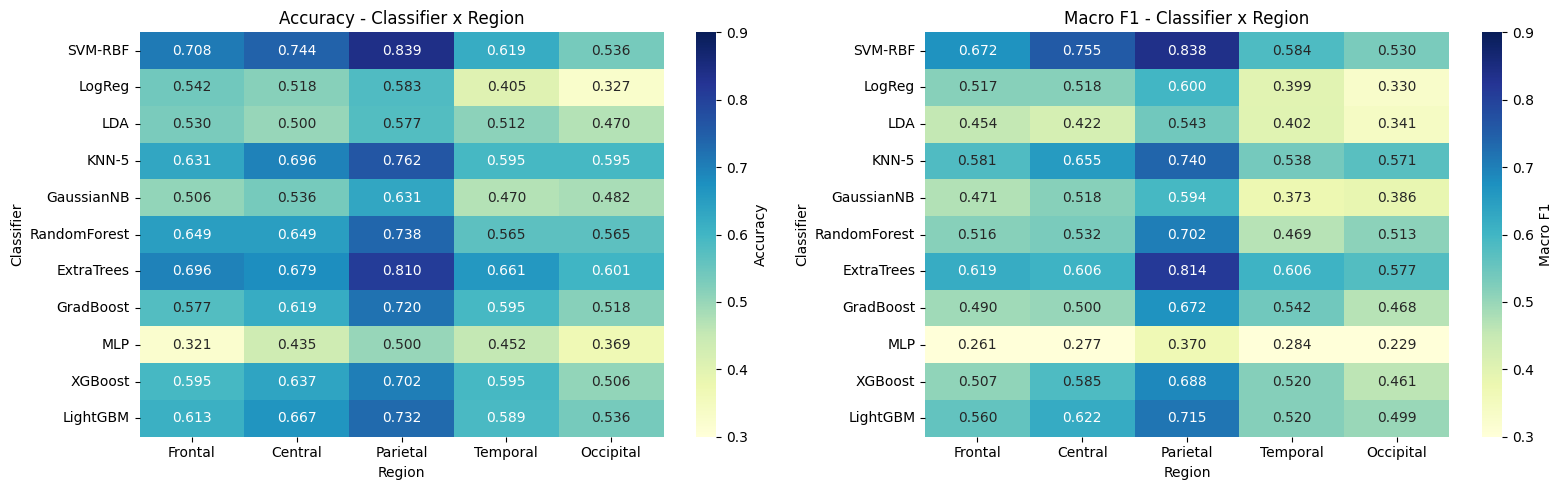

In [ ]:
# Heatmap of all classifier x region
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (title, df) in zip(axes, [('Accuracy', acc_df), ('Macro F1', f1_df)]):
    sns.heatmap(df.T, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0.3, vmax=0.9,
                ax=ax, cbar_kws={'label': title})
    ax.set_title(f'{title} - Classifier x Region')
    ax.set_xlabel('Region'); ax.set_ylabel('Classifier')
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\ML_PLV_BE\ml_plv_be_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

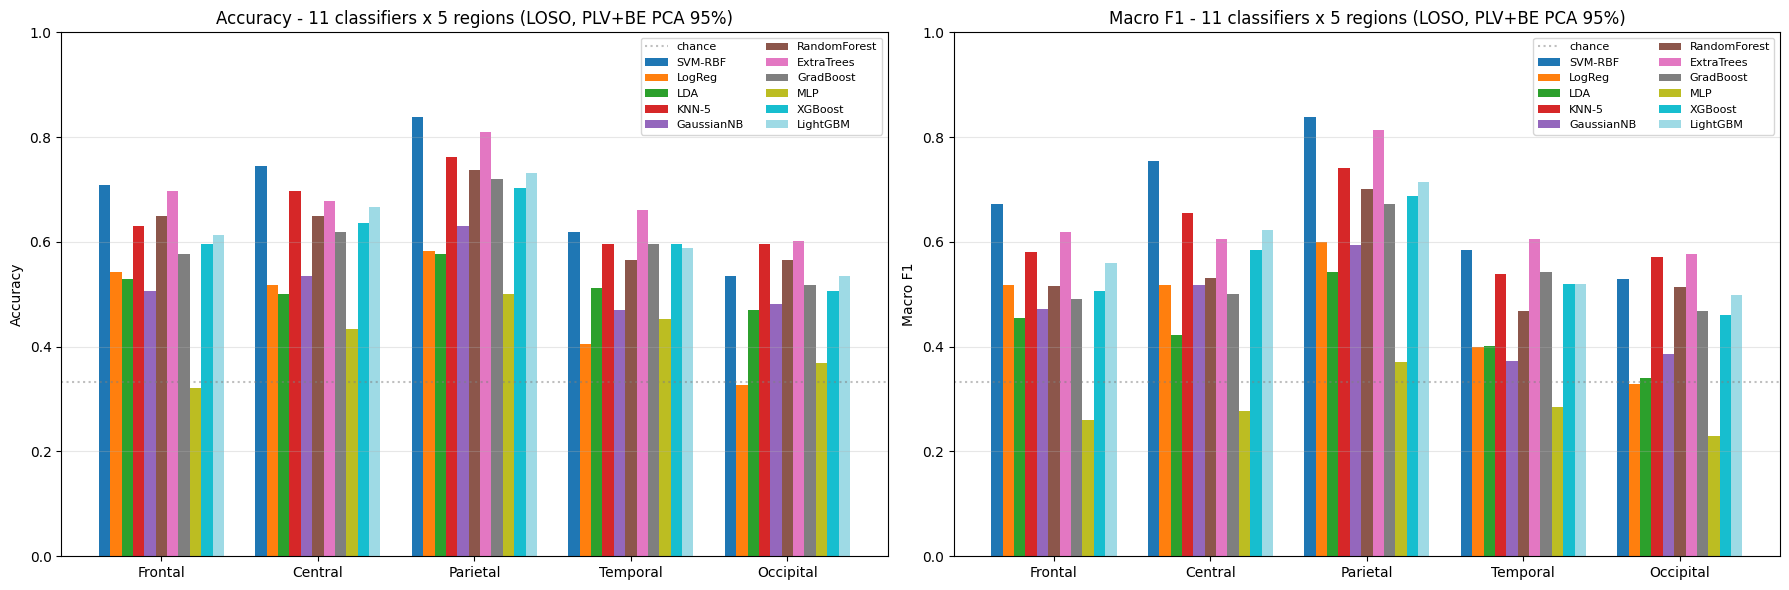

In [ ]:
# Grouped bar chart - Accuracy & F1 across classifiers
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
x = np.arange(len(region_names))
width = 0.8 / len(clf_names)
cmap = plt.get_cmap('tab20', len(clf_names))

for ax_idx, (metric, df, title) in enumerate([('acc', acc_df, 'Accuracy'), ('f1', f1_df, 'Macro F1')]):
    ax = axes[ax_idx]
    for i, clf in enumerate(clf_names):
        vals = df[clf].values
        offset = (i - len(clf_names)/2) * width + width/2
        ax.bar(x + offset, vals, width, label=clf, color=cmap(i))
    ax.set_xticks(x); ax.set_xticklabels(region_names, fontsize=10)
    ax.set_ylabel(title); ax.set_ylim(0, 1)
    ax.axhline(y=1/3, color='gray', linestyle=':', alpha=0.5, label='chance')
    ax.set_title(f'{title} - {len(clf_names)} classifiers x 5 regions (LOSO, PLV+BE PCA 95%)')
    ax.legend(fontsize=8, ncol=2, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\ML_PLV_BE\ml_plv_be_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()

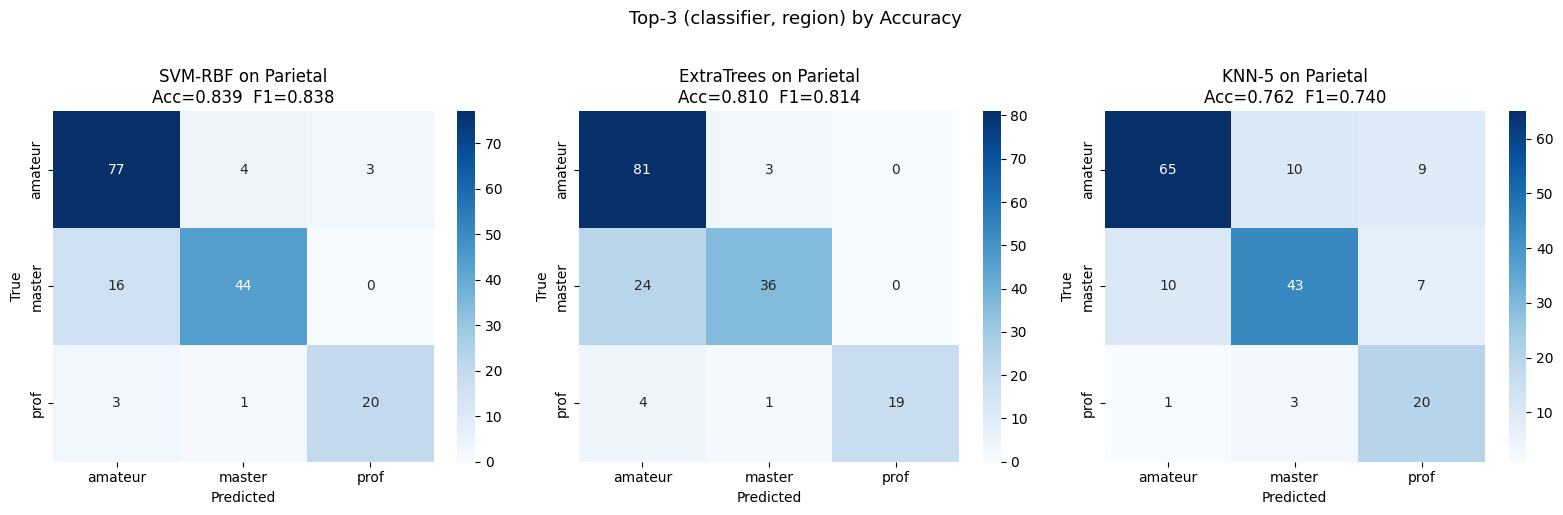


[SVM-RBF on Parietal]  Acc=0.839  F1=0.838
              precision    recall  f1-score   support

     amateur       0.80      0.92      0.86        84
      master       0.90      0.73      0.81        60
        prof       0.87      0.83      0.85        24

    accuracy                           0.84       168
   macro avg       0.86      0.83      0.84       168
weighted avg       0.85      0.84      0.84       168


[ExtraTrees on Parietal]  Acc=0.810  F1=0.814
              precision    recall  f1-score   support

     amateur       0.74      0.96      0.84        84
      master       0.90      0.60      0.72        60
        prof       1.00      0.79      0.88        24

    accuracy                           0.81       168
   macro avg       0.88      0.79      0.81       168
weighted avg       0.84      0.81      0.80       168


[KNN-5 on Parietal]  Acc=0.762  F1=0.740
              precision    recall  f1-score   support

     amateur       0.86      0.77      0.81       

In [ ]:
# Confusion matrices for top-3 (classifier, region) combos by accuracy
scored = []
for clf in clf_names:
    for rn in region_names:
        scored.append((results[clf][rn]['acc'], clf, rn))
scored.sort(reverse=True)
top3 = scored[:3]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (acc, clf, rn) in zip(axes, top3):
    r = results[clf][rn]
    cm = confusion_matrix(r['true'], r['preds'], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{clf} on {rn}\nAcc={r["acc"]:.3f}  F1={r["f1"]:.3f}')

plt.suptitle('Top-3 (classifier, region) by Accuracy', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\ML_PLV_BE\ml_plv_be_top3_cm.png',
            dpi=150, bbox_inches='tight')
plt.show()

for acc, clf, rn in top3:
    r = results[clf][rn]
    print(f'\n[{clf} on {rn}]  Acc={r["acc"]:.3f}  F1={r["f1"]:.3f}')
    print(classification_report(r['true'], r['preds'],
                                target_names=CLASS_NAMES, zero_division=0))

In [ ]:
# Soft-vote subject-level comparison on Parietal (best region)
from scipy import stats

BEST_REGION = 'Parietal'
vote_rows = []
for clf in clf_names:
    r = results[clf][BEST_REGION]
    proba_all = r['proba']
    preds_all = r['preds']
    hard_preds, soft_preds, vote_true = [], [], []
    for i, sub_id in enumerate(subject_ids):
        idx = slice(i*3, i*3+3)
        hard = int(stats.mode(preds_all[idx], keepdims=False).mode)
        soft = int(np.argmax(proba_all[idx].mean(axis=0)))
        hard_preds.append(hard); soft_preds.append(soft)
        vote_true.append(subject_labels[sub_id])
    hard_preds = np.array(hard_preds); soft_preds = np.array(soft_preds); vote_true = np.array(vote_true)
    vote_rows.append({
        'classifier': clf,
        'session_acc': r['acc'],
        'session_f1':  r['f1'],
        'hard_acc': accuracy_score(vote_true, hard_preds),
        'hard_f1':  f1_score(vote_true, hard_preds, average='macro', zero_division=0),
        'soft_acc': accuracy_score(vote_true, soft_preds),
        'soft_f1':  f1_score(vote_true, soft_preds, average='macro', zero_division=0),
    })

vote_df = pd.DataFrame(vote_rows).set_index('classifier')
print(f'=== {BEST_REGION} region: session-level vs hard/soft vote (subject-level) ===')
print(vote_df.round(3).to_string())

vote_df.to_csv(r'D:\Tseng\game_eeg\ML_PLV_BE\ml_plv_be_vote.csv')

=== Parietal region: session-level vs hard/soft vote (subject-level) ===
              session_acc  session_f1  hard_acc  hard_f1  soft_acc  soft_f1
classifier                                                                 
SVM-RBF             0.839       0.838     0.929    0.929     0.946    0.943
LogReg              0.583       0.600     0.768    0.790     0.732    0.738
LDA                 0.577       0.543     0.643    0.563     0.679    0.592
KNN-5               0.762       0.740     0.893    0.867     0.929    0.930
GaussianNB          0.631       0.594     0.696    0.689     0.696    0.691
RandomForest        0.738       0.702     0.804    0.766     0.786    0.750
ExtraTrees          0.810       0.814     0.857    0.868     0.929    0.929
GradBoost           0.720       0.672     0.750    0.657     0.821    0.804
MLP                 0.500       0.370     0.500    0.342     0.536    0.363
XGBoost             0.702       0.688     0.768    0.764     0.768    0.764
LightGBM       